In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = False

#day = datetime.today().strftime('%Y-%m-%d')
day = '2025-03-25'
sample =  'all' # 'randomsample500' 

## Read timeseries stats

In [3]:
metadata = pd.read_csv("./data/combined_tech_characteristics.csv", index_col=0)
ts_stats = pd.read_csv(f"./results/timeseries_stats_{sample}_2024-11-19.csv", index_col=0)
params = pd.read_csv(f"./results/fitting_parameters_{sample}_{day}.csv", index_col=0)
print("number of time series:", len(ts_stats))
print("number of metadata:", len(metadata))
print("number of fit parameter sets:", len(params))

number of time series: 5547
number of metadata: 203
number of fit parameter sets: 49923


In [4]:
# get other metadata from timeseries file
ts = pd.read_csv('data/HATCH_v1.5_clean.csv')
ts_metadata = ts[['ID', 'Spatial Scale', 'Region', 'Country Name', 'Technology Name',
       'Metric', 'Unit', 'Data Source', 'Long Technology Name']]

In [5]:
params = params.loc[params['fit_success']]
metadata['Technology Name'] = metadata.index

In [6]:
# 'technology' and 'tech_name' are unique identifiers for each time series,
# while 'Technology Name' is a field which gives the technology, for which several time series for different countries can exist

full_table = pd.merge(params, ts_stats.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'tech_name')
print(len(full_table))
full_table = pd.merge(full_table, ts_metadata.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'ID')
print(len(full_table))
# full_table = pd.merge(full_table, metadata, how = 'left', left_on = 'Technology Name', right_on='Technology Name')
# print(len(full_table))
# there seem to be duplicate matches, which need to be removed
full_table = full_table.drop_duplicates(subset=params.columns)
print(len(full_table))
full_table

49870
49870
56322
49870


,functional_form,fit_procedure,fit_success,r_squared,adj_r_squared,MCp,BIC,MAPE,a,b,...,ratio_last1m_v_first,tech_name,ID,Spatial Scale,Region,Country Name,Metric,Unit,Data Source,Long Technology Name
0,exponential,curve_fit,True,0.487690,0.481543,7.392699e+03,7.694435e+03,1.051031,100.391781,0.010812,...,-1.423208,Sugar Output_Annual Production_JM,Sugar Output_Annual Production_JM,National,JAM,Jamaica,Annual Production,thousand metric tons,Mitchell,Sugar Output_Annual Production_JM
1,linear,curve_fit,True,0.406591,0.401862,8.497110e+03,8.730111e+03,1.528609,-1800.686448,1.014233,...,-1.423208,Sugar Output_Annual Production_JM,Sugar Output_Annual Production_JM,National,JAM,Jamaica,Annual Production,thousand metric tons,Mitchell,Sugar Output_Annual Production_JM
2,logistic,curve_fit,True,0.706834,0.703316,4.230428e+03,4.403095e+03,0.760129,289.208416,0.201153,...,-1.423208,Sugar Output_Annual Production_JM,Sugar Output_Annual Production_JM,National,JAM,Jamaica,Annual Production,thousand metric tons,Mitchell,Sugar Output_Annual Production_JM
3,gompertz,curve_fit,True,0.699004,0.695392,4.343411e+03,4.520689e+03,0.784392,287.769584,0.171707,...,-1.423208,Sugar Output_Annual Production_JM,Sugar Output_Annual Production_JM,National,JAM,Jamaica,Annual Production,thousand metric tons,Mitchell,Sugar Output_Annual Production_JM
4,softplus,curve_fit,True,0.513636,0.507799,7.018306e+03,7.304761e+03,0.880879,2.500417,0.090887,...,-1.423208,Sugar Output_Annual Production_JM,Sugar Output_Annual Production_JM,National,JAM,Jamaica,Annual Production,thousand metric tons,Mitchell,Sugar Output_Annual Production_JM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56317,softplus,curve_fit,True,0.939718,0.909578,1.087347e+09,1.149038e+09,0.243888,39833.928385,1.002134,...,1.000000,Iron Ore_Annual production_PK,Iron Ore_Annual production_PK,National,PAK,Pakistan,Annual production,metric tons,USGS,Iron Ore_Annual production_PK
56318,logistic-linear-cont,curve_fit,True,0.943906,0.915858,1.011818e+09,1.069223e+09,0.217256,260854.379276,0.613273,...,1.000000,Iron Ore_Annual production_PK,Iron Ore_Annual production_PK,National,PAK,Pakistan,Annual production,metric tons,USGS,Iron Ore_Annual production_PK
56319,bass,curve_fit,True,0.977656,0.959780,4.534191e+08,4.839075e+08,0.206711,312607.699477,0.751756,...,1.000000,Iron Ore_Annual production_PK,Iron Ore_Annual production_PK,National,PAK,Pakistan,Annual production,metric tons,USGS,Iron Ore_Annual production_PK
56320,bertalanffy,curve_fit,True,0.954790,0.932185,8.154841e+08,8.617504e+08,0.314927,361745.557682,0.342127,...,1.000000,Iron Ore_Annual production_PK,Iron Ore_Annual production_PK,National,PAK,Pakistan,Annual production,metric tons,USGS,Iron Ore_Annual production_PK


In [10]:
# correct internally inconsistent labels
full_table['Metric'] = full_table['Metric'].replace({'Annual production': 'Annual Production',
                                                     'Cumulative total capacity': 'Cumulative Total Capacity'})

In [8]:
# mask r_squared values outside of range
full_table['r_squared_masked'] = full_table['r_squared'].mask(full_table['r_squared'] < 0).mask(full_table['r_squared'] > 1)

In [11]:
full_table.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'fit_message', 'int_flat', 'technology', 'Technology Name',
       'd', 'd_std', 'error_type', 'error_msg', 'n', 't_min', 't_max',
       'dt_min', 'dt_max', 'dt_mean', 'dt_std', 'y_median', 'y_mean', 'y_std',
       'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first', 'tech_name', 'ID',
       'Spatial Scale', 'Region', 'Country Name', 'Metric', 'Unit',
       'Data Source', 'Long Technology Name'],
      dt

# Uncertainty

In [10]:
full_table['b_std_norm'] = (full_table['b_std'] / full_table['b'])
full_table['b_std_norm'] = full_table['b_std_norm'].mask(full_table['b_std_norm'] <= 0)
full_table['b_std_norm_log'] = full_table['b_std_norm'].apply(np.log10)

<Axes: >

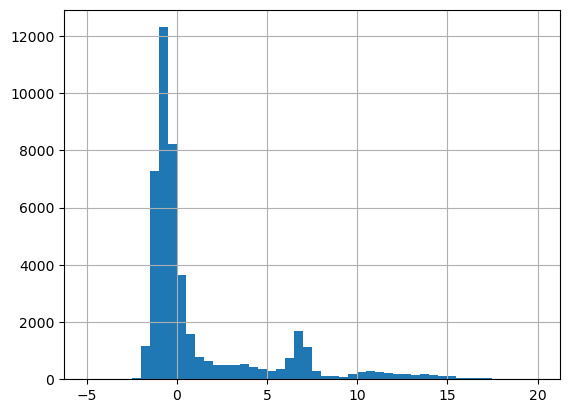

In [11]:
# full_table['b_std_norm_log'].hist(bins=50, range=[-5, 20])
full_table.loc[full_table['functional_form'] == 'linear', 'b_std_norm_log'].hist(bins=50, range=[-5, 20])

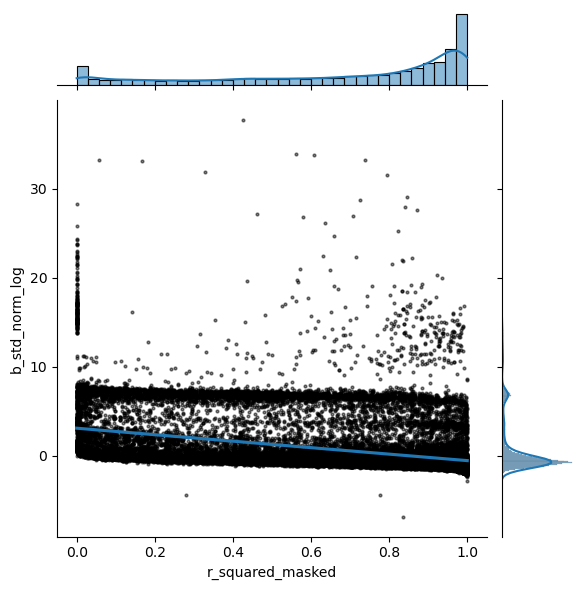

In [12]:
sns.jointplot(data=full_table, y='b_std_norm_log', x='r_squared_masked', kind="reg", scatter_kws={'s': 4, 'color':'k', 'alpha':0.5})
if save_fig:
    plt.savefig(f'figures/{sample}_{day}_b_uncertainty_over_r2.png', **savefig_settings)

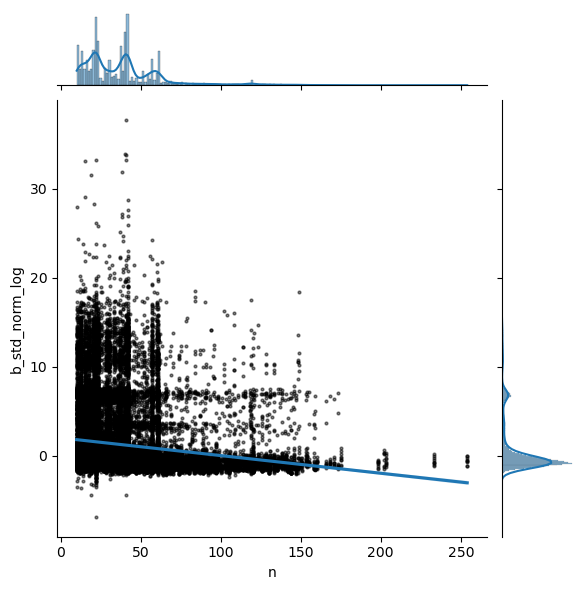

In [13]:
sns.jointplot(data=full_table, y='b_std_norm_log', x='n', kind="reg", scatter_kws={'s': 4, 'color':'k', 'alpha':0.5})
if save_fig:
    plt.savefig(f'figures/{sample}_{day}_b_uncertainty_over_n.png', **savefig_settings)

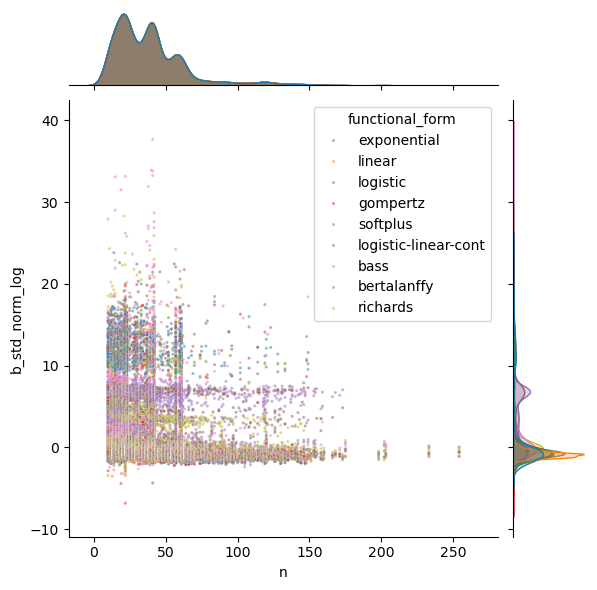

In [14]:
sns.jointplot(data=full_table, y='b_std_norm_log', x='n', hue='functional_form', s= 5, alpha = 0.5)

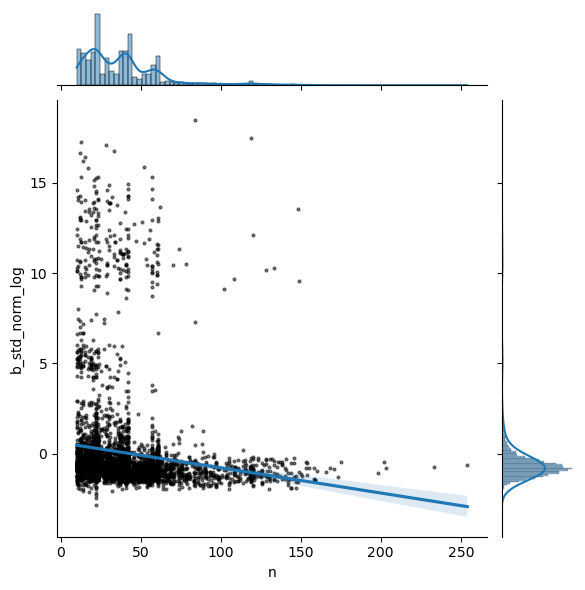

In [15]:
sns.jointplot(data=full_table[full_table['functional_form'] == 'logistic'], y='b_std_norm_log', x='n', kind="reg", scatter_kws={'s': 4, 'color':'k', 'alpha':0.5})

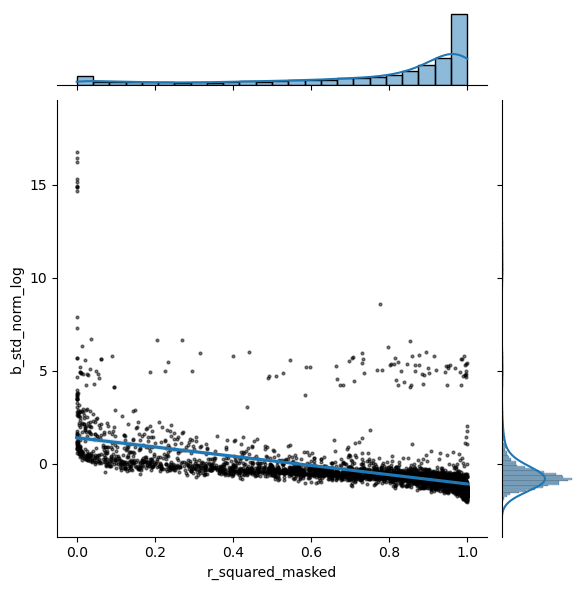

In [16]:
sns.jointplot(data=full_table[full_table['functional_form'] == 'logistic'], y='b_std_norm_log', x='r_squared_masked', kind="reg", scatter_kws={'s': 4, 'color':'k', 'alpha':0.5})

In [17]:
full_table[full_table['b_std_norm_log'] > 5]['functional_form'].value_counts()

functional_form
logistic-linear-cont    2609
softplus                2127
exponential              866
bass                     624
richards                 444
gompertz                 346
logistic                 288
bertalanffy               87
Name: count, dtype: int64

In [18]:
full_table.groupby('functional_form')['b_std_norm_log'].describe()

,count,mean,std,min,25%,50%,75%,max
functional_form,,,,,,,,
bass,4783.0,1.601305,4.270650,-3.278685,-0.497629,-0.001595,1.400388,37.677804
bertalanffy,4684.0,-0.439713,1.261755,-2.483500,-1.012408,-0.683155,-0.308887,8.893243
exponential,5545.0,1.212854,4.760682,-2.194166,-1.066881,-0.718154,-0.219973,23.808487
gompertz,5004.0,0.236423,3.055534,-6.830633,-0.938497,-0.626025,-0.222009,22.186983
linear,4624.0,-0.827436,0.461870,-3.538222,-1.150630,-0.862936,-0.586274,1.733542
logistic,5079.0,0.060496,2.787113,-2.833698,-1.036976,-0.705665,-0.258776,18.465407
logistic-linear-cont,5539.0,4.117821,4.841562,-2.042214,-0.474397,3.676453,6.990425,22.450545
richards,5046.0,1.390009,3.279577,-3.041547,-0.319911,0.123261,1.507812,28.299198
softplus,5545.0,3.107839,3.236482,-1.966999,-0.262019,3.077321,6.600531,8.288777


In [19]:
full_table.groupby('functional_form')['b_std_norm_log'].agg(['mean', 'std', 'median'])

,mean,std,median
functional_form,,,
bass,1.601305,4.270650,-0.001595
bertalanffy,-0.439713,1.261755,-0.683155
exponential,1.212854,4.760682,-0.718154
gompertz,0.236423,3.055534,-0.626025
linear,-0.827436,0.461870,-0.862936
logistic,0.060496,2.787113,-0.705665
logistic-linear-cont,4.117821,4.841562,3.676453
richards,1.390009,3.279577,0.123261
softplus,3.107839,3.236482,3.077321


In [20]:
map_n_pars = {'exponential': 2,
              'linear': 2,
              'logistic': 3,
              'gompertz': 3,
              'softplus': 3,
              'logistic-linear-cont': 3,
              'bass': 4,
              'bertalanffy': 3,
              'richards': 4}
full_table['n_func_pars'] = full_table['functional_form'].map(map_n_pars)

In [21]:
full_table.groupby('n_func_pars')['b_std_norm_log'].agg(['mean', 'std', 'median'])

,mean,std,median
n_func_pars,,,
2,0.285103,3.672414,-0.796113
3,1.526915,3.782838,-0.385521
4,1.492830,3.795602,0.062509


Text(-96.30555555555556, 0.5, '')

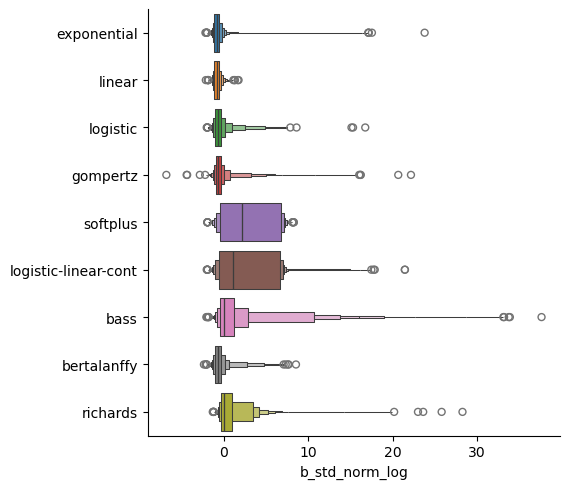

In [22]:
# distribution of uncertainty
sns.catplot(y='functional_form', x='b_std_norm_log', hue='functional_form',
            data=full_table[full_table["r_squared"] > 0], kind='boxen', legend=False, aspect=1.2)
plt.ylabel('')

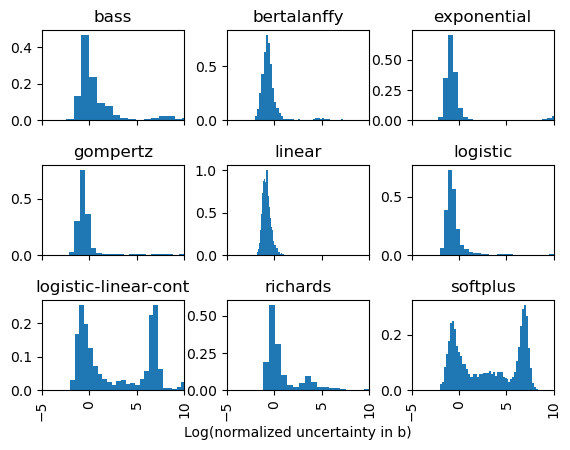

In [23]:
# distribution of uncertainty
full_table.hist(column='b_std_norm_log', by='functional_form', bins=50, sharex=True, density=True)
plt.xlim([-5, 10])
fig = plt.gcf()
axs = fig.get_axes()
axs[-2].set_xlabel('Log(normalized uncertainty in b)')

if save_fig:
    plt.savefig(f'figures/{sample}_{day}_b_uncertainty_distributions_per_ff.png', **savefig_settings)

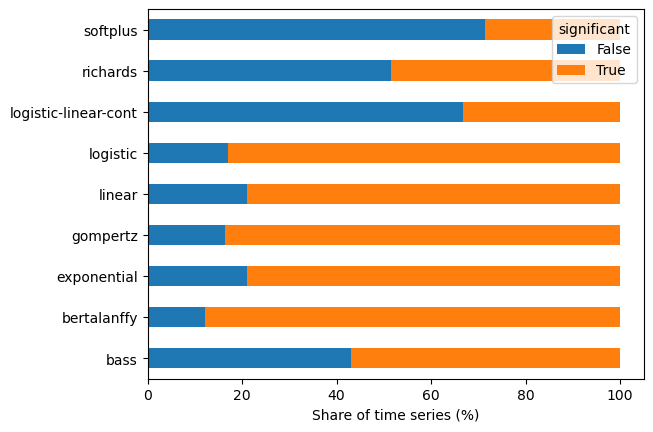

In [24]:
full_table['significant'] = full_table['b'] > full_table['b_std']
(100 * full_table.groupby('functional_form')['significant'].value_counts(normalize=True).unstack()).plot.barh(stacked=True)
plt.xlabel('Share of time series (%)')
plt.ylabel('')
if save_fig:
    plt.savefig(f'figures/{sample}_{day}_b_std_less_b.png', **savefig_settings)

In [ ]:
full_table['b'].notna().groupby(full_table['functional_form']).sum()
# same for b_std

functional_form
bass                    5547
bertalanffy             5547
exponential             5547
gompertz                5547
linear                  5547
logistic                5547
logistic-linear-cont    5547
richards                5494
softplus                5547
Name: b, dtype: int64

In [ ]:
# characteristics of time series with large uncertainties
ftable = full_table[(full_table['b_std_norm_log'] > 5) & full_table['functional_form'].isin(['softplus', 'logistic-linear-cont'])]
ftable[['r_squared', 'r_squared_masked', 'adj_r_squared', 'b', 'n', 'roughness']].describe()

,r_squared,r_squared_masked,adj_r_squared,b,n,roughness
count,4736.000000,3876.000000,4736.000000,4.736000e+03,4736.000000,4736.000000
mean,0.348754,0.426506,0.250199,1.140522e+00,35.882812,0.471454
std,0.298010,0.274189,0.359568,6.887854e+00,22.146731,0.168730
min,-0.216749,0.000000,-0.518186,1.729747e-25,10.000000,0.044576
25%,0.034273,0.189394,-0.061953,6.804661e-03,21.000000,0.342173
50%,0.327824,0.426901,0.240808,7.516435e-02,36.000000,0.481902
75%,0.578548,0.637315,0.521841,3.501940e-01,42.000000,0.592616
max,0.998048,0.998048,0.997890,1.000000e+02,173.000000,0.924754


In [ ]:
ftable2 = full_table[(full_table['b_std_norm_log'] < 5) & full_table['functional_form'].isin(['softplus', 'logistic-linear-cont'])]
ftable2[['r_squared', 'r_squared_masked', 'adj_r_squared', 'b', 'n', 'roughness']].describe()

/home/finn/miniconda3/envs/datenv2/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/finn/miniconda3/envs/datenv2/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,r_squared,r_squared_masked,adj_r_squared,b,n,roughness
count,6348.000000,5433.000000,6348.000000,6.348000e+03,6348.000000,6348.000000
mean,-inf,0.785353,-inf,5.753231e-01,40.938248,0.415630
std,NaN,0.281091,NaN,3.058070e+00,27.725147,0.197916
min,-inf,0.000000,-inf,9.036948e-23,10.000000,0.000000
25%,0.383789,0.703544,0.297900,1.828131e-02,22.000000,0.274185
50%,0.881102,0.918318,0.867306,1.003616e-01,36.000000,0.441779
75%,0.972453,0.979426,0.968872,3.020809e-01,55.000000,0.560406
max,1.000000,1.000000,0.999999,1.000000e+02,254.000000,0.924754


### Notes

Large uncertainty in log-lin and softplus seems to 